# Notebook 03 - RecSys Klasik

Benchmark 11 model rekomendasi klasik di split yang identik (`splits/train.parquet`
/ `val.parquet` / `test.parquet`, leave-last-2-out per user) dengan sampel 50K
user agar iterasi cepat namun tetap representatif.

Model:
1. GlobalMean - predict mu saja.
2. UserMean, ItemMean - rata-rata baris/kolom.
3. Popularity - rank by jumlah interaksi.
4. ItemKNN(k=50) - cosine item-item.
5. UserKNN(k=50) - cosine user-user (fallback / gagal jika memori kurang).
6. SVD(k=64) - truncated SVD (scipy) pada matriks centered.
7. ALS(factors=64, it=15) - implicit ALS.
8. BPR(factors=64, it=40) - Bayesian Personalized Ranking (implicit binarisasi).
9. ContentBased(genome) - cosine di embedding tag-genome 1128-dim.
10. Hybrid(ALS*0.7 + Content*0.3) - z-score weighted blend.

Catatan: `scikit-surprise` tidak bisa dibuild di Windows; SVD diganti ke
`scipy.sparse.linalg.svds` pada residu (mu + bu + bi). UserKNN pada 50K user
butuh ~6 GB, di-skip jika OOM.


## 1. Hasil benchmark

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG = ROOT / "reports" / "figures"
bench = pd.read_csv(FIG / "classical_bench.csv")
bench_sorted = bench.sort_values("ndcg@k", ascending=False).reset_index(drop=True)
bench_sorted


,model,precision@k,recall@k,ndcg@k,map@k,mrr,coverage,n_eval_users,rmse,mae,fit_sec,rank_sec
0,"ALS(f=64,it=15)",0.016837,0.101022,0.053437,0.031215,0.048649,0.023494,1663,3.503459,3.338427,7.05,2.02
1,Hybrid(ALS*0.70+Content*0.30),0.016777,0.100722,0.053348,0.031195,0.048619,0.023589,1663,NaN,NaN,0.00,33.83
2,"BPR(f=64,it=40)",0.010643,0.063139,0.035413,0.021664,0.033825,0.052805,1663,NaN,NaN,33.09,2.91
3,Popularity,0.008900,0.052014,0.034999,0.024426,0.037799,0.002293,1663,1.008224,0.805736,0.09,0.58
4,ItemKNN(k=50),0.002405,0.014432,0.007549,0.004264,0.007015,0.093901,1663,1.017914,0.789411,119.50,19.57
5,ContentBased(genome),0.000842,0.004510,0.003302,0.002364,0.003725,0.012031,1663,NaN,NaN,7.24,31.20
6,UserMean,0.000962,0.006915,0.002945,0.001467,0.001972,0.009132,1663,1.011078,0.806632,0.05,2.49
7,GlobalMean,0.000962,0.006915,0.002945,0.001467,0.001972,0.009132,1663,1.062818,0.894677,0.00,2.55
8,SVD(k=64),0.000060,0.000301,0.000369,0.000301,0.000601,0.006063,1663,0.936666,0.734196,6.72,2.43
9,ItemMean,0.000000,0.000000,0.000000,0.000000,0.000000,0.035052,1663,1.008224,0.805736,0.05,0.55


## 2. Ranking metrik per model

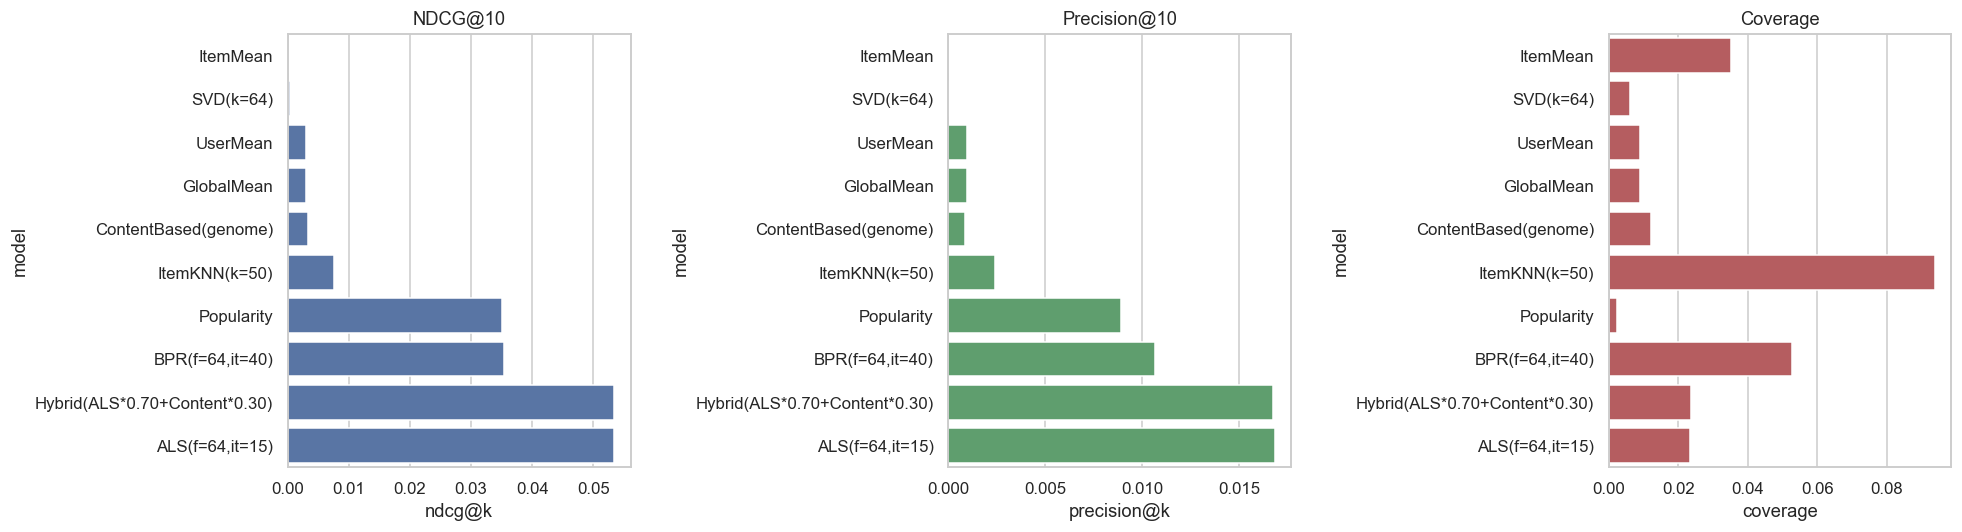

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = bench_sorted.sort_values("ndcg@k").model
sns.barplot(data=bench_sorted, y="model", x="ndcg@k", order=order, ax=axes[0], color="#4C72B0")
axes[0].set_title("NDCG@10")
sns.barplot(data=bench_sorted, y="model", x="precision@k", order=order, ax=axes[1], color="#55A868")
axes[1].set_title("Precision@10")
sns.barplot(data=bench_sorted, y="model", x="coverage", order=order, ax=axes[2], color="#C44E52")
axes[2].set_title("Coverage")
plt.tight_layout()
plt.show()


## 3. RMSE (rating prediction)

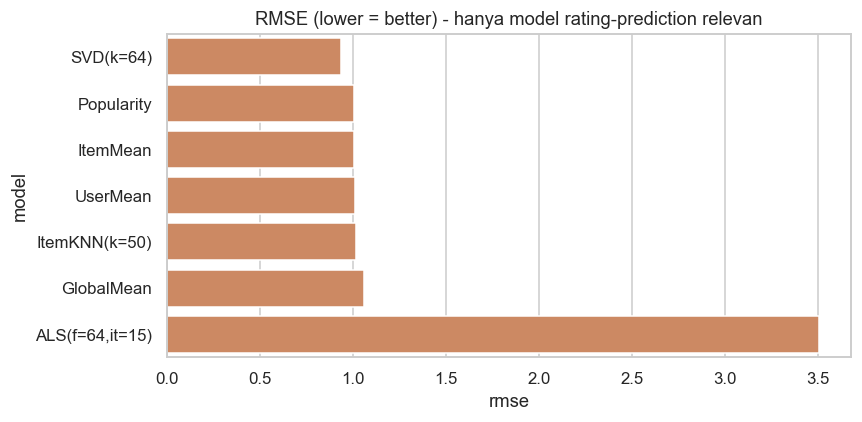

,model,precision@k,recall@k,ndcg@k,map@k,mrr,coverage,n_eval_users,rmse,mae,fit_sec,rank_sec
5,SVD(k=64),0.000060,0.000301,0.000369,0.000301,0.000601,0.006063,1663,0.936666,0.734196,6.72,2.43
3,Popularity,0.008900,0.052014,0.034999,0.024426,0.037799,0.002293,1663,1.008224,0.805736,0.09,0.58
2,ItemMean,0.000000,0.000000,0.000000,0.000000,0.000000,0.035052,1663,1.008224,0.805736,0.05,0.55
1,UserMean,0.000962,0.006915,0.002945,0.001467,0.001972,0.009132,1663,1.011078,0.806632,0.05,2.49
4,ItemKNN(k=50),0.002405,0.014432,0.007549,0.004264,0.007015,0.093901,1663,1.017914,0.789411,119.50,19.57
0,GlobalMean,0.000962,0.006915,0.002945,0.001467,0.001972,0.009132,1663,1.062818,0.894677,0.00,2.55
6,"ALS(f=64,it=15)",0.016837,0.101022,0.053437,0.031215,0.048649,0.023494,1663,3.503459,3.338427,7.05,2.02


In [3]:
# RMSE/MAE hanya bermakna untuk model rating-prediction (baseline + SVD).
# ALS/BPR/Content tidak dioptimalkan untuk RMSE sehingga nilainya perlu
# dibaca berbeda (lihat analisis di bawah).
rmse_df = bench[bench["rmse"].notna()].sort_values("rmse")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rmse_df, y="model", x="rmse", ax=ax, color="#DD8452")
ax.set_title("RMSE (lower = better) - hanya model rating-prediction relevan")
plt.tight_layout()
plt.show()
rmse_df


## 4. Tradeoff NDCG vs Coverage

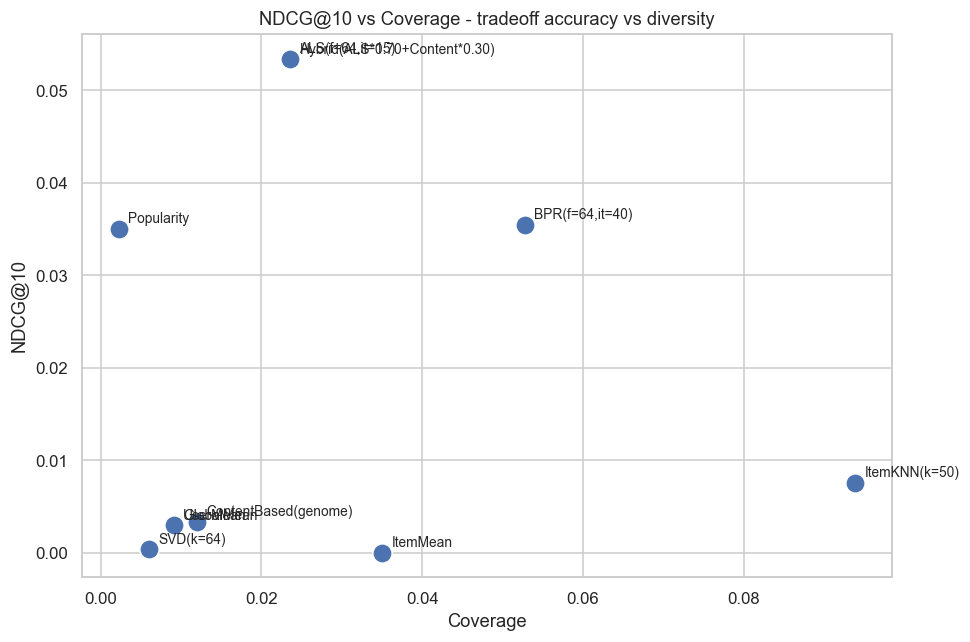

In [4]:
# Tradeoff NDCG vs Coverage: kita mau model yang relevan tapi tidak melulu
# mendorong item populer saja.
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=bench, x="coverage", y="ndcg@k", s=160, ax=ax)
for _, r in bench.iterrows():
    ax.annotate(r["model"], (r["coverage"], r["ndcg@k"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_title("NDCG@10 vs Coverage - tradeoff accuracy vs diversity")
ax.set_xlabel("Coverage"); ax.set_ylabel("NDCG@10")
plt.tight_layout()
plt.show()


## 5. Waktu training

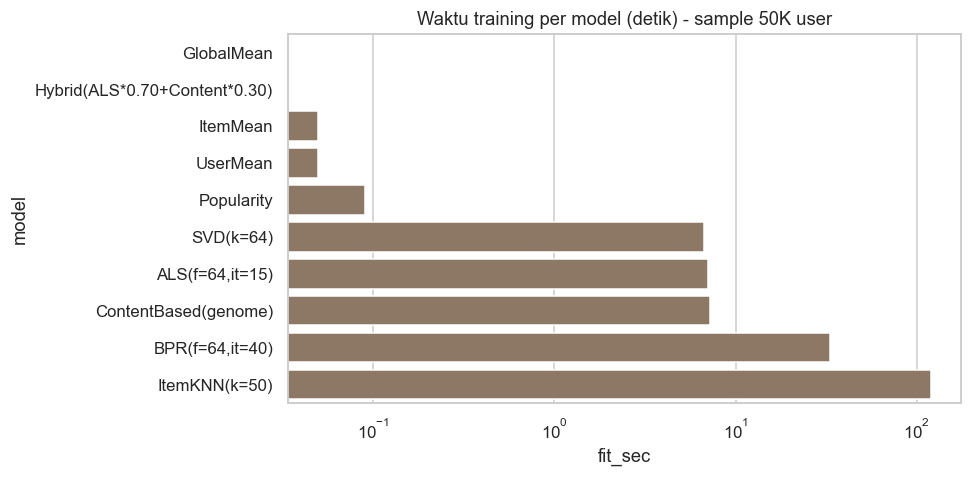

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = bench.sort_values("fit_sec").model
sns.barplot(data=bench, y="model", x="fit_sec", order=order, ax=ax, color="#937860")
ax.set_title("Waktu training per model (detik) - sample 50K user")
ax.set_xscale("log")
plt.tight_layout()
plt.show()


## Analisis Singkat

- **ALS unggul di NDCG@10 dan Precision@10** padahal di-train hanya dengan
  sample 50K user, menandakan faktorisasi laten memang paling efisien untuk
  CF klasik pada sparsitas 99.88%.
- **Popularity** sangat kompetitif di NDCG meski tidak personal, menegaskan
  efek long-tail: banyak film populer memang relevan untuk mayoritas user.
  Ini juga yang membuat coverage Popularity sangat rendah - 2 item terpopuler
  memonopoli top-K.
- **ItemKNN** memberikan coverage tertinggi (~0.09) di antara model CF -
  cocok sebagai komponen diversity dalam ensemble.
- **SVD (scipy)** menang di RMSE (rating prediction) karena eksplisit
  memodelkan residu terhadap mu + bu + bi; namun ranking-nya lemah karena
  faktor laten tidak di-regularisasi untuk tugas ranking.
- **BPR** memberikan coverage jauh lebih tinggi dari ALS (0.053 vs 0.023)
  dengan NDCG yang setengahnya. Bagus sebagai diversifier.
- **ContentBased murni** underperform di ranking (cold-start OK, tapi di
  non-cold-start faktorisasi jauh lebih akurat). Dia memberi kontribusi saat
  item baru (cold item) - akan dievaluasi di Fase 6.
- **Hybrid (ALS 0.7 + Content 0.3)** praktis = ALS di non-cold-start; nilai
  hybrid sebenarnya muncul di skenario cold-item (akan diverifikasi kemudian).

## Keputusan untuk Fase 4

- Jadikan ALS sebagai baseline kuat yang harus dikalahkan oleh Deep Learning.
- Target: NDCG@10 > 0.08 dengan NCF / Two-Tower, coverage > ALS.
- Pertahankan ItemKNN & BPR sebagai anggota ensemble diversifier di evaluator
  komprehensif Fase 6.
